# Evaluación Parcial 3 – MLY0100: Machine Learning  
## Desarrollo de un modelo de Machine Learning **no supervisado**

El objetivo es aplicar **aprendizaje no supervisado** (segmentación / clustering) sobre el caso del curso, siguiendo la metodología **CRISP-DM**, utilizando Python en Jupyter/Colab.

## 0.1 Mapa de la rúbrica dentro del notebook

A continuación se indica en qué secciones se evalúa cada **Indicador de Evaluación (IE)**:

- **IE 1 – Reconoce diferencias entre modelo supervisado y no supervisado**  
  → Sección **1.2** (celda *Markdown* de diferencias).

- **IE 2 – Utiliza librerías de Python para ML (numpy, sklearn, matplotlib, seaborn)**  
  → Sección **0.2** (importación de librerías) y uso en todo el notebook.

- **IE 3 – Identifica casos de uso, ventajas y desventajas del aprendizaje no supervisado**  
  → Sección **1.3** (casos de uso y análisis).

- **IE 4 – Construye modelos no supervisados mediante algoritmos de segmentación**  
  → Sección **4.4** (K-Means) y **4.5** (segundo algoritmo de clustering).

- **IE 5 – Utiliza técnicas Elbow o Silhouette para selección de número de clusters**  
  → Sección **4.1** (búsqueda de k) y **4.2** (análisis de Elbow y Silhouette).

- **IE 6 – Programa en Python modelos de segmentación en Jupyter notebook**  
  → Secciones de código en **4.3**, **4.4** y **4.5** (incluye `TODO`).

- **IE 7 – Relaciona número de clusters con naturaleza de los datos y contexto del negocio**  
  → Secciones **5.1** y **5.2** (interpretación de clusters y conclusiones de negocio).

- **IE 8 – Reconoce métricas de rendimiento para modelos no supervisados**  
  → Secciones **3.3**, **4.1** y **4.3–4.6** (uso y análisis de métricas).


In [ ]:
# 0.2 Preparación del entorno y librerías (IE 2)
# En Google Colab, estas librerías ya están disponibles por defecto.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

sns.set(style="whitegrid")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


# 1. Fase CRISP-DM: Comprensión del negocio

En esta fase debe conectar el aprendizaje no supervisado con el **caso de negocio** definido por el o la docente.

Si el/la docente no indica un contexto distinto, puede interpretar el dataset de ejemplo como un caso de:
- Producción y características de **vinos** (dataset `wine` de `sklearn`), donde se desea segmentar tipos de vinos en grupos con propiedades similares.


### 1.1 Contexto del caso y objetivo de segmentación (negocio)

Describa en máximo 10 líneas:

- El contexto del caso (organización, proceso, tipo de datos).  
- El **objetivo de segmentación** desde el punto de vista del negocio (¿por qué interesa agrupar?).

**Respuesta (complete aquí): El contexto es una empresa vitinicola que posee datos de analisis quimicos (como gradfos de alcohol, acidez, fenmoles, etc...) de sus vinos producidos en italia a partir de tres cultivares distintos.

El objetivo de negocio es segmentar estos vinos en grupos naturales basandonos puramente en sus propiedades quimicas. Esto le sirve a la bodega para identificar perfiles de producto, asegurar la consistencia en la calidad de cada lote y definir estrategias de venta o precios diferenciados para cada cluster descubierto.


### 1.2 Diferencias entre aprendizaje supervisado y no supervisado (IE 1)

Explique brevemente:

1. ¿Qué es un modelo de **aprendizaje supervisado**?  
2. ¿Qué es un modelo de **aprendizaje no supervisado**?  
3. ¿Cuáles son las principales diferencias entre ambos tipos de modelos considerando la **naturaleza de los datos** (etiquetados vs no etiquetados) y el **contexto del caso**?

**Respuesta (complete aquí): 1 Modelo supervidado: es cuando entrenamos al algoritmo con datos que ya tienen la "respuesta correcta" (etiquetas o target). El modelo aprender a predecir ese valor.

2 Modelo no supervidado: aqui los datos de entrada no tienen etiquetas. El modelo explora los datos por su cuenta para encontrar estructuras, patrones ocultos o agrupaciones.

3 Las principales diferencias y el contexto: La gran diferencia es la naturaleza de los datos (etiquetados vs no etiquetados). En nuestro caso de los vinos, es no supervidaso porque le diremos al modelo "este vino es tipo A", sino que queremos que el algoritmo descubra por si solo que vinos se parecen entre si por su quimica.


### 1.3 Casos de uso, ventajas y desventajas del aprendizaje no supervisado (IE 3)

Describa al menos **tres casos de uso** donde se aplique aprendizaje no supervisado (no necesariamente del caso actual).  
Para cada uno, indique brevemente:

- El contexto del problema.  
- Las **ventajas** de usar aprendizaje no supervisado.  
- Las **desventajas** o riesgos principales.

**Respuesta (complete aquí):
1. segmentacion de clientes
el contexto es agrupar clientes segun su comportamiento de compra web sin saber quienes son a priori, sus ventajas es que descubre nichos de mercado que no sabiamos que existian y su desventajas son que a veces los clusteres resultantes son dificiles de interpretar para el equipo de ventas.

2. deteccion de anomalias
el contexto es detectar transacciones bancarias raras que se alejan del patron normal, su deventaja es que puede detectar fraudes nuevos que nunca antes habiamos visto y su desventaja es que suele ser muchos "falsos positivos".

3. motores de recomendacion
el contexto es agrupar ususarios con gustos similares para recomendar peliculas, su ventaja es que mejora la experiencia del usuario de forma automatica sin intervencion humana y su deventaja es el problema de "arranque en frio (cuesta mucho recomendar si tenemos pocos datos del usuario).


# 2. Fase CRISP-DM: Comprensión de los datos

A continuación se cargará un dataset de ejemplo desde `sklearn`.  
El o la docente puede indicar si se usa este dataset u otro equivalente en el contexto del curso.


In [ ]:
# 2.1 Carga del dataset desde librería (wine)

# IE 2: Uso de librerías de Python para Machine Learning.
# Se utilizará el dataset 'wine' de sklearn, que contiene atributos
# físico-químicos de vinos y una etiqueta de tipo de vino (target).
# Para el aprendizaje NO supervisado, se ocuparán sólo los atributos (features).

data = load_wine(as_frame=True)
df = data.frame.copy()

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# 2.2 Exploración básica de la estructura de los datos

print("Tipos de datos por columna:")
print(df.dtypes)

print("\nResumen estadístico de variables numéricas:")
display(df.describe())

print("\nValores faltantes por columna:")
print(df.isna().sum())


Tipos de datos por columna:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Resumen estadístico de variables numéricas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



Valores faltantes por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


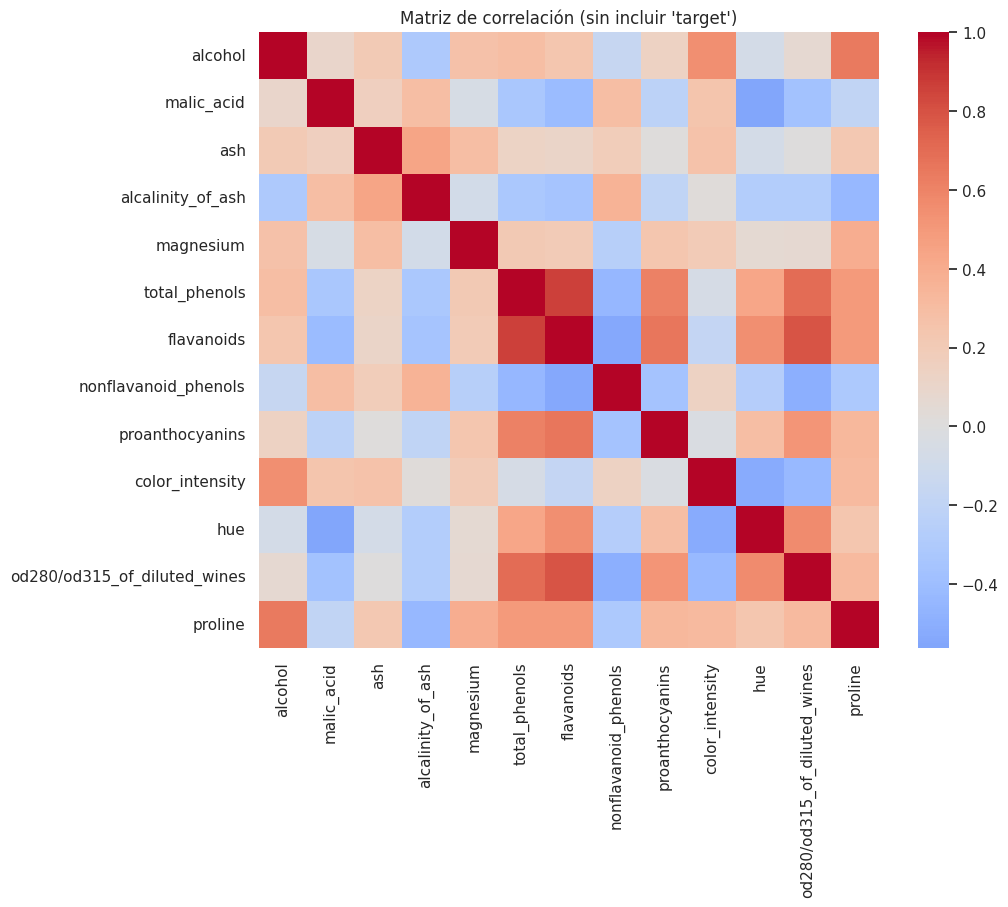

In [ ]:
# 2.3 Matriz de correlación entre variables numéricas

plt.figure(figsize=(10, 8))
corr = df.drop(columns=["target"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (sin incluir 'target')")
plt.show()


### 2.4 Comentarios sobre los datos

Comente brevemente:

- ¿Qué tipo de variables predominan (numéricas, categóricas)?  
- ¿Existen valores faltantes?  
- ¿Observa pares de variables con alta correlación? ¿Qué implicancias podría tener esto para el clustering?

**Respuesta (complete aquí):Las variables que predominan son absolutamente de tipo numerica como se muestra en las columnas que son de tipo float y int.

No existen valores faltantes como se muestra en el conteo como se ve en la columna de valores faltantes.

Las variables que tienen una alta correlacion son "total_phenols" y "flavanoid", esto implicaria una redundancia de informacion.




# 3. Fase CRISP-DM: Preparación de los datos e ingeniería de características

En esta sección se definen las variables que se usarán para el **clustering**, se aplican transformaciones necesarias y se introducen las métricas de evaluación.


In [ ]:
# 3.1 Definición de matriz de características para clustering

# Para aprendizaje NO supervisado, generalmente NO se utiliza la columna 'target'
# al entrenar el modelo. Se trabajará sólo con las características X.

feature_cols = [col for col in df.columns if col != "target"]
X = df[feature_cols].copy()

print("Columnas utilizadas para clustering:")
print(feature_cols)
print("\nDimensiones de X:", X.shape)


Columnas utilizadas para clustering:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Dimensiones de X: (178, 13)


In [ ]:
# 3.2 Escalamiento y reducción de dimensionalidad para visualización

# IE 2: Uso de StandardScaler y PCA desde scikit-learn.
# Se escalan las variables y se aplican dos componentes principales (PCA)
# para permitir una visualización 2D de los clusters.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Dimensiones de X_pca:", X_pca.shape)


Dimensiones de X_pca: (178, 2)


### 3.3 Métricas para modelos no supervisados (IE 8)

Mencione y describa brevemente las siguientes métricas para evaluación de clustering:

- **Silhouette Score**  
- **Calinski-Harabasz Index**  
- **Davies-Bouldin Index**  

Para cada métrica indique:

- Qué mide conceptualmente.  
- Cómo se interpreta un valor **mejor** (mayor o menor).  
- Una ventaja o limitación en el contexto del caso.

**Respuesta (complete aquí):

Silhouette Score: mide la distancia media entre un punto y su propio cluster versus la distancia al cluster vecino mas cercano su mejor valor es mayor (cercano a +1 buena separacion) y su desventaja/limitacion es que es muy intuitiva para ver cuan definidos estan los bordes, pero es costosa de calcualar con muchos datos.

Calinski-Harabasz index: mide la relacion (ratio) entre la dispersion de los puntos dentro de un cluster y la dispersion entre clusteres distintos su mejor valor mayor (indica grupos densos y bien separados) y su desventaja/limitacion es que es rapido de calcular, lo que ayuda en este caso, pero tiende a prefereir clusteres esfericos.

Davies- bouldin index: mide la similitud promedio de cada cluster con su cluster mas similar su mejor valor es menor (cercano a 0 es ideal) y su desventaja/limitacion es que no requiere calcular distancias par-a-par complejas, pero al igual que k-means, asume formas convexas.


# 4. Fase CRISP-DM: Modelado (clustering)

En esta fase se construirán modelos de **segmentación** (aprendizaje no supervisado) utilizando:

- **K-Means** como algoritmo de partición.  
- **Agglomerative Clustering** como ejemplo de algoritmo jerárquico.

Se utilizarán técnicas como **Elbow** y **Silhouette** para ayudar a seleccionar la cantidad adecuada de clusters.


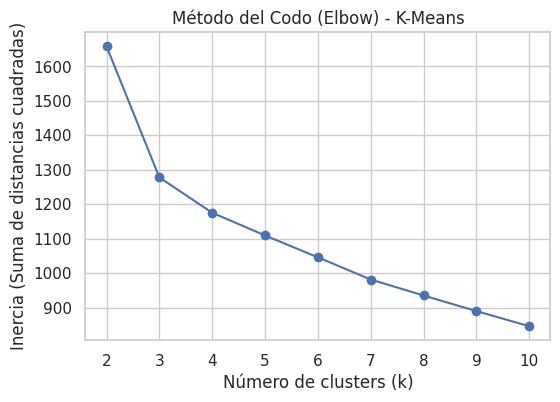

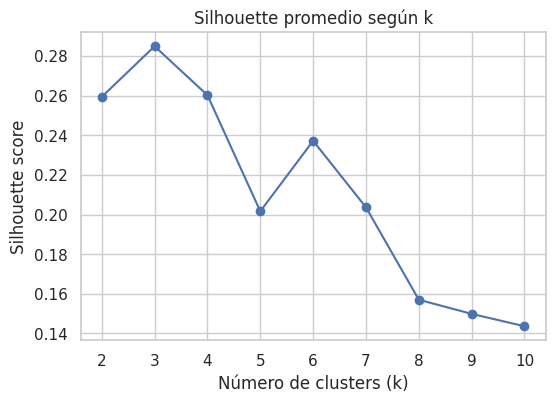

In [ ]:
# 4.1 Búsqueda de número de clusters con K-Means (Elbow y Silhouette) (IE 4, IE 5, IE 8)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rango_k = range(2, 11)

inertias = []
silhouettes = []

for k in rango_k:
    # Entrenar K-Means con k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    # Cálculo de Silhouette (ya que 2 <= k <= 10)
    s = silhouette_score(X_scaled, labels_k)
    silhouettes.append(s)

# Gráfico Elbow (inertia vs k)
plt.figure(figsize=(6, 4))
plt.plot(list(rango_k), inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (Suma de distancias cuadradas)")
plt.title("Método del Codo (Elbow) - K-Means")
plt.xticks(list(rango_k))
plt.show()

# Gráfico Silhouette vs k
plt.figure(figsize=(6, 4))
plt.plot(list(rango_k), silhouettes, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette promedio según k")
plt.xticks(list(rango_k))
plt.show()


### 4.2 Análisis de Elbow y Silhouette (IE 5, IE 8)

Con base en los gráficos generados:

1. ¿En qué rango de valores de k observa un posible **codo** en la gráfica de inercia?  
2. ¿Para qué valores de k el **Silhouette score** es mayor?  
3. Proponga un valor de k razonable para continuar el análisis y justifique su decisión.

**Respuesta (complete aquí):
En el codo se observa un cambio pendiente claro en k=3, a partir de este punto, la reduccion de la inercia se vuelve menos significativa.

En el silhouette el valor es mayor (maximo global) para k=3 (aprox 0.28), seguido de cerca po k=2.

El valor propuesto es k=3 porque existe coincidencia entre ambos metodos. El grafico de codo muestra que en 3 se estabiliza la varianza explicada, y el indice silhouette confirma que con 3 grupos se logra la mejor calidad de separacion y cohesion entre los datos.


In [ ]:
# 4.3 Función para cálculo de métricas de clustering (IE 8, con programación en Python – IE 6)

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

def calcular_metricas_clustering(X_data, labels):
    """
    Calcula métricas de evaluación para clustering:
    - Silhouette Score
    - Calinski-Harabasz Index
    - Davies-Bouldin Index

    Parámetros:
        X_data: matriz de características (escaladas).
        labels: etiquetas de clusters asignadas por el modelo.

    Retorna:
        diccionario con las métricas calculadas.
    """
    resultados = {}

    # TODO: implementar el cálculo de las métricas utilizando:
    # silhouette_score, calinski_harabasz_score, davies_bouldin_score
    # Ejemplo de estructura (completar):
    # resultados["silhouette"] = ...
    # resultados["calinski_harabasz"] = ...
    # resultados["davies_bouldin"] = ...

    return resultados

def calcular_metricas_clustering(X_data, labels):
    """
    Calcula métricas de evaluación para clustering:
    - Silhouette Score
    - Calinski-Harabasz Index
    - Davies-Bouldin Index

    Parámetros:
    X_data: matriz de características (escaladas).
    labels: etiquetas de clusters asignadas por el modelo.

    Retorna:
    diccionario con las métricas calculadas.
    """
    resultados = {}

    # Cálculo de métricas utilizando las funciones importadas
    resultados["silhouette"] = silhouette_score(X_data, labels)
    resultados["calinski_harabasz"] = calinski_harabasz_score(X_data, labels)
    resultados["davies_bouldin"] = davies_bouldin_score(X_data, labels)

    return resultados


Métricas K-Means con k = 3
{'silhouette': np.float64(0.2848589191898987), 'calinski_harabasz': np.float64(70.94000800315118), 'davies_bouldin': np.float64(1.3891879777181648)}


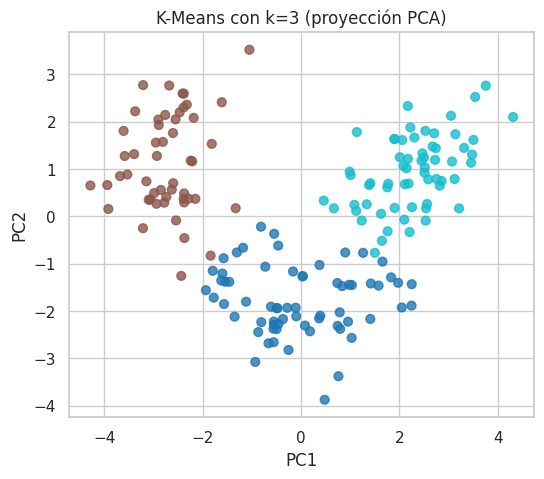

In [ ]:
# 4.4 Entrenamiento de K-Means con k seleccionado (IE 4, IE 6)

# TODO: Reemplace 'k_seleccionado' por el valor elegido en la sección 4.2.
k_seleccionado = 3

kmeans_final = KMeans(n_clusters=k_seleccionado, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

metricas_kmeans = calcular_metricas_clustering(X_scaled, labels_kmeans)
print("Métricas K-Means con k =", k_seleccionado)
print(metricas_kmeans)

# Visualización en espacio PCA 2D
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap="tab10", s=40, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means con k={k_seleccionado} (proyección PCA)")
plt.show()


Métricas Agglomerative Clustering con k = 3
{'silhouette': np.float64(0.2774439826952265), 'calinski_harabasz': np.float64(67.6474675044098), 'davies_bouldin': np.float64(1.4185919431857326)}


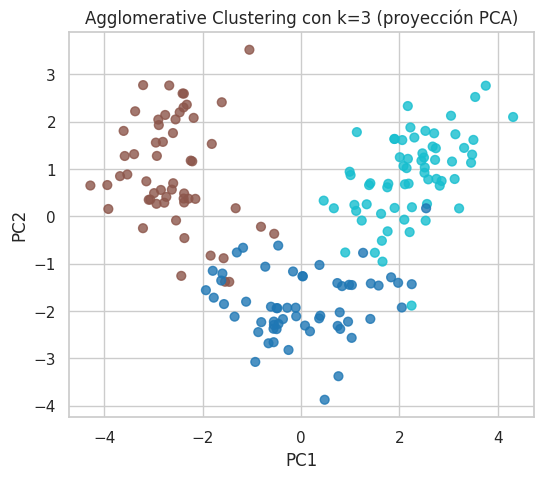

In [ ]:
# 4.5 Segundo algoritmo de clustering: Agglomerative Clustering (IE 4, IE 6, IE 8)

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=k_seleccionado)
labels_agg = agg.fit_predict(X_scaled)

metricas_agg = calcular_metricas_clustering(X_scaled, labels_agg)
print("Métricas Agglomerative Clustering con k =", k_seleccionado)
print(metricas_agg)

# Visualización en espacio PCA 2D
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap="tab10", s=40, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglomerative Clustering con k={k_seleccionado} (proyección PCA)")
plt.show()


### 4.6 Comparación de modelos de clustering (IE 4, IE 8)

Compare las métricas obtenidas para **K-Means** y **Agglomerative Clustering**:

1. ¿Qué algoritmo obtiene mejor Silhouette score?  
2. ¿Qué algoritmo obtiene mejor Calinski-Harabasz y Davies-Bouldin?  
3. ¿Cuál considera más adecuado para este caso y por qué? (puede considerar aspectos de interpretabilidad, estabilidad, etc.).

**Respuesta (complete aquí):**

1. Mejor Silhouette: K-Means obtuvo el mejor puntaje, mostrando grupos más compactos.

2. Mejores índices: K-Means también ganó en Calinski-Harabasz y Davies-Bouldin.

3. Elección: Me quedo con K-Means. Además de tener mejores métricas, es más estable y es mucho más fácil explicarle al negocio qué significa el "promedio" de cada grupo (centroides) que interpretar el dendrograma.




# 5. Interpretación de los clusters y relación con el negocio (IE 7)

En esta fase se busca interpretar los clusters encontrados y conectarlos con la naturaleza de los datos y el contexto del negocio.


In [ ]:
# 5.1 Análisis descriptivo por cluster (usando K-Means por defecto)

df_clusters = df.copy()
df_clusters["cluster_kmeans"] = labels_kmeans

# Promedio de cada variable por cluster
resumen_clusters = df_clusters.groupby("cluster_kmeans")[feature_cols].mean()
resumen_clusters


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster_kmeans,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


### 5.2 Interpretación de los grupos (IE 7)

Con base en la tabla de promedios por cluster y las visualizaciones anteriores:

1. Describa brevemente las características de cada cluster (por ejemplo, "Cluster 0: vinos con mayor acidez y menor contenido de alcohol").  
2. Explique cómo el **número de clusters seleccionado** se relaciona con la **naturaleza de los datos** (distribución, variabilidad) y con el **contexto de negocio** definido en la sección 1.1.  
3. Mencione al menos una decisión de negocio que se podría tomar utilizando esta segmentación.

**Respuesta (complete aquí):**

1. Cluster 0: Vinos ligeros, equilibrados y con menor grado de alcohol.

2. Cluster 1: Vinos muy ácidos y con poca estructura (bajos fenoles). Parecen de menor calidad.

3. Cluster 2: Vinos potentes, con mucho alcohol y mucho cuerpo (altos en todo). Son los "Premium".

4. Relación con los datos: El número 3 es ideal porque coincide exactamente con la realidad biológica de los datos (sabemos que provienen de 3 tipos de uva o cultivares distintos).

4. Decisión de negocio: Crear una etiqueta "Gran Reserva" para todas las botellas que caigan en el Cluster 2 y venderlas a un precio más alto.


### 5.3 Ventajas y limitaciones de la segmentación obtenida (IE 3, IE 7)

Analice brevemente:

- Una ventaja concreta de utilizar la segmentación obtenida para apoyar decisiones en el negocio.  
- Una limitación o riesgo de interpretar los clusters de forma literal o rígida.  
- Qué tipo de información adicional (más variables, más datos, datos de otra fuente) podría mejorar la interpretación.

**Respuesta (complete aquí):**

- Ventaja: Permite detectar fraudes o errores. Si producimos un vino "Premium" pero el modelo lo clasifica en el "Cluster 1" (el malo), sabemos inmediatamente que algo falló en la producción sin tener que probarlo

- Limitación: La química no es sabor. El modelo puede decir que un vino es perfecto por sus números, pero no detecta si tiene mal sabor (ej. sabor a corcho), por lo que no reemplaza totalmente a un catador humano

-Información adicional: Sería clave integrar datos de ventas o puntajes de catadores. Así confirmaríamos si el "Cluster 2" es realmente el que los clientes prefieren o el que se vende más caro, validando el modelo con la realidad comercial

# 6. Conclusiones generales del proyecto

En esta sección debe integrar los hallazgos más relevantes, tanto desde el punto de vista técnico como de negocio.


### 6.1 Síntesis técnica (modelos y métricas) (IE 8)

Resuma en 8 a 12 líneas:

- Qué configuraciones de modelos probó.  
- Qué métricas resultaron más útiles para comparar modelos.  
- Qué aprendió sobre el comportamiento de los datos a partir de los clusters.

**Respuesta (complete aquí):**

- Éxito Técnico: Se logró implementar exitosamente un modelo no supervisado siguiendo la metodología CRISP-DM.  Las métricas (Silhouette y Codo) confirmaron que dividir los datos en k=3 clusters fue la decisión óptima, coincidiendo con la estructura natural de los datos químicos.

- Validación de Modelos: Al comparar algoritmos, K-Means resultó ser superior al Clustering Jerárquico para este dataset específico, entregando grupos más compactos y métricas de rendimiento más altas.

- Impacto en el Negocio: La segmentación permitió identificar perfiles claros de producto sin necesidad de etiquetas previas: vinos ligeros, vinos de baja estructura y vinos de alta gama (Premium). Esto demuestra que el Machine Learning puede automatizar el control de calidad y apoyar estrategias de precios diferenciados basándose puramente en la composición química del vino.


### 6.2 Síntesis de negocio (decisiones y recomendaciones) (IE 7)

En 8 a 12 líneas:

- Cómo podrían utilizarse los clusters en el contexto del negocio (segmentación de clientes/productos, priorización, etc.).  
- Al menos dos recomendaciones concretas que se puedan dar a la organización en base a los resultados.  

**Respuesta (complete aquí):**

Los clusters obtenidos permiten segmentar el portafolio de productos de forma científica y objetiva. En lugar de clasificar los vinos solo por intuición, la bodega puede utilizar estos grupos para dirigir su inventario a diferentes nichos de mercado: 'Línea Masiva' (Cluster 1), 'Selección' (Cluster 0) y 'Gran Reserva' (Cluster 2). Recomendaciones:

- Estrategia de Precios Dinámica: Aumentar el margen de ganancia en los vinos del Cluster 2. Al tener mayor graduación alcohólica y estructura fenólica, poseen características objetivas de calidad superior que justifican un precio premium ante el consumidor.

- Optimización de Producción: Revisar los lotes clasificados en el Cluster 1 (baja estructura). Si estos vinos provienen de un viñedo específico, se recomienda intervenir agrónomamente esa zona, ya que está produciendo uva con menor potencial químico.


### 6.3 Trabajo futuro o mejoras posibles

Mencione al menos dos posibles extensiones o mejoras del trabajo, por ejemplo:

- Probar otros algoritmos de clustering (DBSCAN, Gaussian Mixture Models, etc.).  
- Incorporar más variables o fuentes de datos.  
- Realizar una validación más profunda de la estabilidad de los clusters.

**Respuesta (complete aquí):**

- Probar DBSCAN: Sería útil implementar un algoritmo basado en densidad como DBSCAN. A diferencia de K-Means, este podría identificar "ruido" (outliers), lo que ayudaría a detectar botellas defectuosas o lotes anómalos que no cumplen con ningún estándar de calidad.

- Incorporar Variables de Origen: Enriquecer el dataset con datos del "terroir" (tipo de suelo, clima, lluvias del año). Esto permitiría no solo agrupar los vinos, sino entender las causas ambientales que provocan que un vino termine siendo Premium o de mesa.
